In [20]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt
from tensorflow.python.keras.saving.saved_model import metric_serialization

### Load Data

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


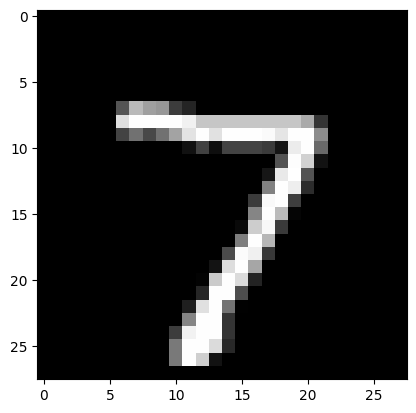

In [7]:
plt.imshow(X_test[0], cmap='gray')

### Processing The Data

In [9]:
X_train = X_train.reshape(60000,784).astype('float32')
X_valid = X_test.reshape(10000,784).astype('float32')

X_train /= 255
X_valid /= 255

In [10]:
n_classes = 10
y_train = to_categorical(y_train, n_classes)
y_valid = to_categorical(y_test,n_classes)

### Implementing the Neural Network

In [14]:
import warnings
warnings.filterwarnings('ignore')
model = Sequential()
# hidden layer
model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(BatchNormalization())

#second hidden layer
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())

# third hidden layer
model.add(Dropout(0.2))

#output layer
model.add(Dense(10, activation='softmax'))
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,562 (217.04 KB)

 Trainable params: 55,306 (216.04 KB)

 Non-trainable params: 256 (1.00 KB)

In [15]:
model.compile(loss='categorical_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])

In [16]:
model.fit(X_train, y_train, batch_size=128, epochs = 128, verbose =1, validation_data = (X_valid, y_valid))

Epoch 1/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8775 - loss: 0.4168 - val_accuracy: 0.7970 - val_loss: 9.5849
Epoch 2/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.9372 - loss: 0.2154 - val_accuracy: 0.8492 - val_loss: 37.1506
Epoch 3/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - accuracy: 0.9470 - loss: 0.1765 - val_accuracy: 0.8333 - val_loss: 48.2072
Epoch 4/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - accuracy: 0.9542 - loss: 0.1519 - val_accuracy: 0.8408 - val_loss: 53.8081
Epoch 5/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - accuracy: 0.9575 - loss: 0.1388 - val_accuracy: 0.7974 - val_loss: 75.2268
Epoch 6/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - accuracy: 0.9622 - loss: 0.1234 - val_accuracy: 0.8196 - val_loss: 66.0966
Epoch 7/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - accuracy: 0.9646 - loss: 0.1157 - val_accuracy: 0.8376 - val_loss: 57.6540
Epoch 8/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - accuracy: 0.9664 - los

In [17]:
test_loss, test_acc = model.evaluate(X_valid, y_valid, verbose=0)

In [18]:
print(f"Test loss: {test_loss:.4f} Test accuracy: {test_acc:.4f}")

Test loss: 244.6493 Test accuracy: 0.7755


In [21]:
predictions = model.predict(X_valid[:5], verbose=0)
predictions_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_valid[:5], axis=1)

print("Predicted classes: ", predictions_classes)
print("True classes: ", true_classes, end="")

Predicted classes:  [7 2 1 0 4]
True classes:  [7 2 1 0 4]